# Seasonal Agriculture Performance Analysis

This notebook analyzes seasonal agricultural performance using the provided dataset to compare yield, profitability, resource use, and climate conditions across Kharif, Rabi, and Zaid seasons.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("data/seasonal_agriculture_performance_dataset.csv")
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1. Dataset overview

The dataset contains agricultural farm records across states, districts, crops, and seasons. It includes crop, production, revenue, profit, environmental, soil, and irrigation variables.


In [ ]:
df.info()
df.shape
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

Rainfall_mm           48
Soil_Moisture_pct     40
Yield_Tonnes_Ha       32
Farm_ID                0
Crop                   0
District               0
Farm_Area_Hectares     0
Season                 0
Avg_Temperature_C      0
Humidity_pct           0
dtype: int64

In [ ]:
df.duplicated().sum()
df["Season"].value_counts()


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

## 2. Data cleaning and preprocessing

The dataset contains a small number of missing values in numerical fields. These are filled with the median value for each column so they do not distort the analysis.


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df["Season"] = pd.Categorical(df["Season"], categories=["Kharif", "Rabi", "Zaid"], ordered=True)
df.isna().sum().sum()


np.int64(0)

In [ ]:
season_summary = df.groupby("Season", observed=True).agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Total_Cost_INR": "mean"
}).reset_index()
season_summary.round(2)


,Season,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Avg_Temperature_C,Total_Cost_INR
0,Kharif,5.63,178914.65,849.20,28.45,531804.41
1,Rabi,5.04,87689.47,437.62,23.49,513836.58
2,Zaid,4.64,-24804.82,304.65,31.04,543976.73


## 3. Seasonal comparison of productivity and profitability

Kharif generally delivers the strongest performance due to favorable rainfall and temperature conditions. Rabi remains stable, while Zaid shows lower productivity and negative average profit.


C:\Users\Maddula Dinesh Reddy\AppData\Local\Temp\ipykernel_1928\3456886549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_summary, x="Season", y="Yield_Tonnes_Ha", palette="Set2", ax=axes[0,0])
C:\Users\Maddula Dinesh Reddy\AppData\Local\Temp\ipykernel_1928\3456886549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_summary, x="Season", y="Profit_INR", palette="Set2", ax=axes[0,1])
C:\Users\Maddula Dinesh Reddy\AppData\Local\Temp\ipykernel_1928\3456886549.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(da

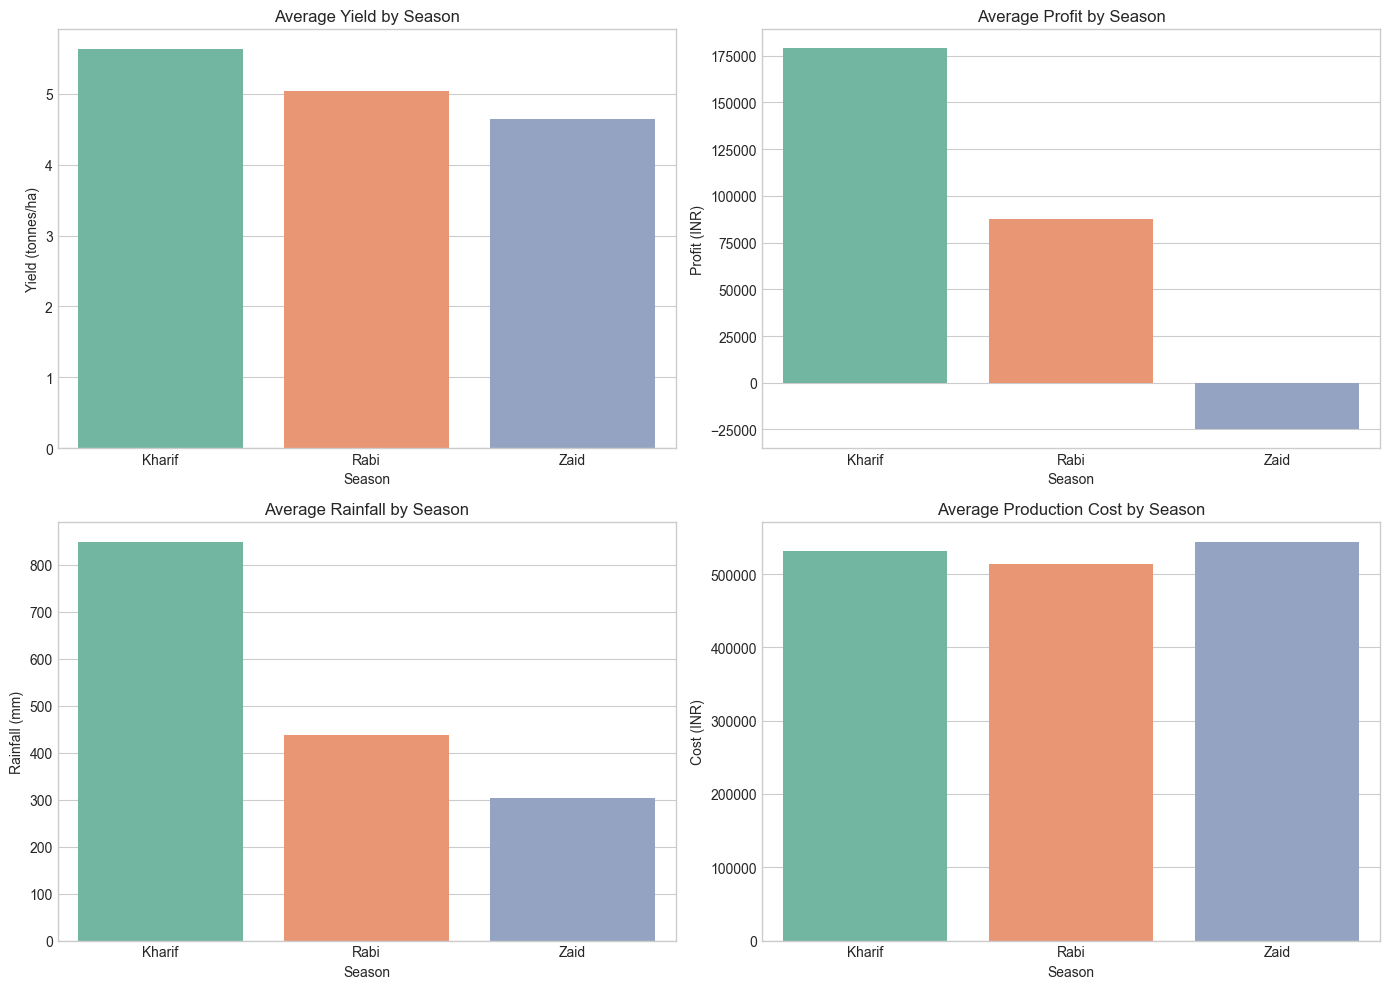

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=season_summary, x="Season", y="Yield_Tonnes_Ha", palette="Set2", ax=axes[0,0])
axes[0,0].set_title("Average Yield by Season")
axes[0,0].set_ylabel("Yield (tonnes/ha)")

sns.barplot(data=season_summary, x="Season", y="Profit_INR", palette="Set2", ax=axes[0,1])
axes[0,1].set_title("Average Profit by Season")
axes[0,1].set_ylabel("Profit (INR)")

sns.barplot(data=season_summary, x="Season", y="Rainfall_mm", palette="Set2", ax=axes[1,0])
axes[1,0].set_title("Average Rainfall by Season")
axes[1,0].set_ylabel("Rainfall (mm)")

sns.barplot(data=season_summary, x="Season", y="Total_Cost_INR", palette="Set2", ax=axes[1,1])
axes[1,1].set_title("Average Production Cost by Season")
axes[1,1].set_ylabel("Cost (INR)")

plt.tight_layout()


C:\Users\Maddula Dinesh Reddy\AppData\Local\Temp\ipykernel_1928\2967235787.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2")


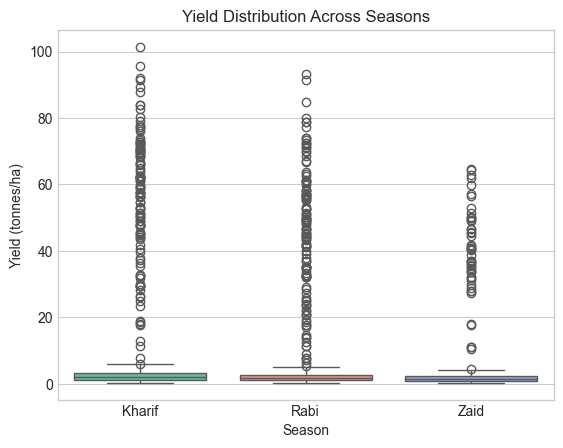

In [ ]:
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2")
plt.title("Yield Distribution Across Seasons")
plt.ylabel("Yield (tonnes/ha)")
plt.show()


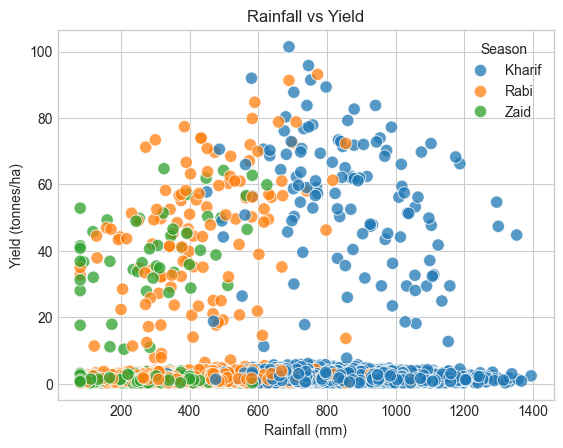

In [ ]:
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", s=80, alpha=0.75)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.show()


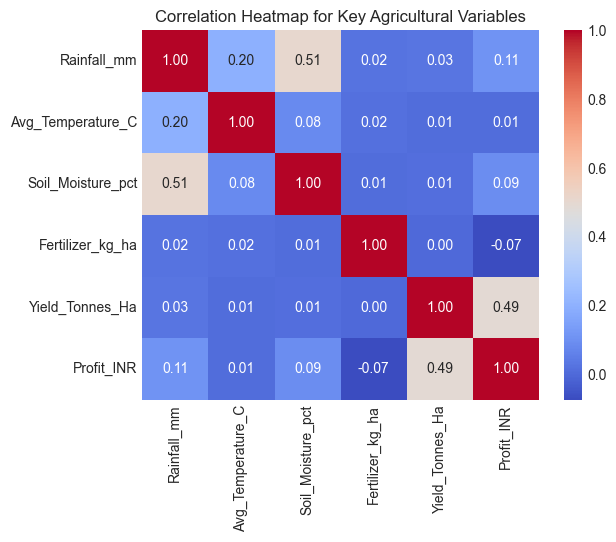

In [ ]:
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Soil_Moisture_pct", "Fertilizer_kg_ha", "Yield_Tonnes_Ha", "Profit_INR"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Key Agricultural Variables")
plt.show()


## 4. Crop and irrigation insights

Profitability varies strongly across crop types and irrigation methods. Sugarcane and chilli are among the highest-profit crops, while drip irrigation supports the strongest average returns.


In [ ]:
crop_summary = df.groupby("Crop", observed=True).agg({
    "Profit_INR": "mean",
    "Yield_Tonnes_Ha": "mean"
}).reset_index().sort_values("Profit_INR", ascending=False)
crop_summary.head(10)


,Crop,Profit_INR,Yield_Tonnes_Ha
6,Sugarcane,817187.986885,46.642361
0,Chilli,750878.342233,1.542767
1,Cotton,124546.915354,1.229783
2,Groundnut,44858.120283,1.322901
4,Pulses,-4238.052419,0.921512
3,Maize,-83978.326679,2.710036
5,Rice,-102213.504348,2.431304
7,Wheat,-123398.337134,2.108013


C:\Users\Maddula Dinesh Reddy\AppData\Local\Temp\ipykernel_1928\60669093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=irrigation_summary, x="Irrigation_Method", y="Profit_INR", palette="viridis")


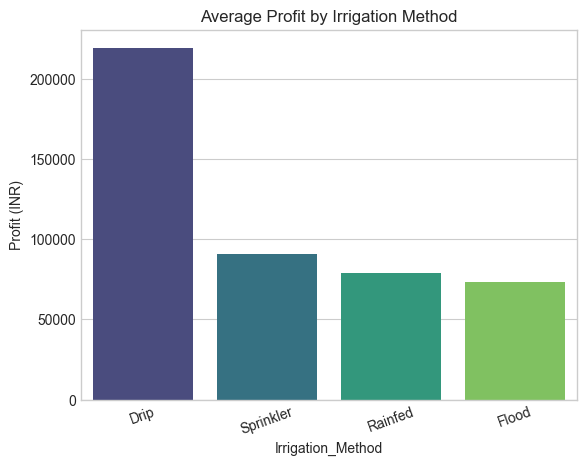

In [ ]:
irrigation_summary = df.groupby("Irrigation_Method", observed=True)["Profit_INR"].mean().reset_index().sort_values("Profit_INR", ascending=False)
sns.barplot(data=irrigation_summary, x="Irrigation_Method", y="Profit_INR", palette="viridis")
plt.title("Average Profit by Irrigation Method")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=20)
plt.show()


## 5. Key findings and recommendations

The analysis shows that Kharif is the most productive and profitable season, while Zaid records lower output and negative average profit. Seasonal rainfall and crop suitability strongly influence performance, and drip irrigation appears to improve economic returns.

### Recommendations
- Prioritize Kharif crop planning for high-yield and income-oriented crops.
- Improve water management and irrigation efficiency during low-rainfall seasons.
- Promote high-profit crops such as sugarcane and chilli in suitable regions.
- Strengthen pest and disease monitoring during Zaid conditions.
- Use data-driven seasonal planning to minimize cost and improve profitability.


In [ ]:
best_season = season_summary.sort_values("Profit_INR", ascending=False).iloc[0]
best_crop = crop_summary.head(1).iloc[0]
best_irrigation = irrigation_summary.head(1).iloc[0]
print("Best performing season by average profit:", best_season["Season"], f"({best_season["Profit_INR"]:.2f} INR)")
print("Highest profit crop:", best_crop["Crop"], f"({best_crop["Profit_INR"]:.2f} INR)")
print("Best irrigation method:", best_irrigation["Irrigation_Method"], f"({best_irrigation["Profit_INR"]:.2f} INR)")


Best performing season by average profit: Kharif (178914.65 INR)
Highest profit crop: Sugarcane (817187.99 INR)
Best irrigation method: Drip (219626.00 INR)


## 6. Conclusion

Seasonal agricultural performance varies significantly due to rainfall distribution, temperature conditions, crop type, and irrigation efficiency. By understanding these seasonal patterns, farmers and planners can improve productivity, reduce risk, and increase profitability across different seasons.
